In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from subqcat.io import XeniumBundle
from subqcat.subsample import XeniumSampler
from subqcat.clustering import SpatialClusterer
from subqcat.quality import QCEvaluator
from subqcat.viz import SubQCATPlotter

In [3]:
bundle = XeniumBundle("/Users/priyaltripathi/SubQCAT/data/Xenium_Prime_Mouse_Brain_Coronal_FF_outs")
df = XeniumSampler(bundle)
subsampled_df = df.subsample()

In [4]:
df_grouped_by_cell = subsampled_df.groupby('cell_id')

In [ ]:
from scipy.spatial import Delaunay

triangulation = []
for cell_id, group in df_grouped_by_cell:
    if len(group) < 4:
        triangulation.append({'cell_id': cell_id, 'edge_length_variance': np.nan})
        continue
    coords = group[['x_location', 'y_location']].values
    tri = Delaunay(coords)
    edges = set()
    for simplex in tri.simplices:  
        for i in range(3):
            edge = tuple(sorted([simplex[i], simplex[(i+1) % 3]]))
            edges.add(edge)
    
    edge_lengths = []
    for i, j in edges:
        length = np.linalg.norm(coords[i] - coords[j])
        edge_lengths.append(length)
    
    triangulation.append({
        'cell_id': cell_id, 
        'edge_length_variance': np.var(edge_lengths)
    })

results = pd.DataFrame(triangulation)


In [13]:
results['log_variance'] = np.log1p(results['edge_length_variance'])


In [ ]:

clusterer = SpatialClusterer(results)
clustered_df = clusterer.kMeans_clustering("log_variance", 2)

In [ ]:

qc = QCEvaluator(clustered_df, bundle)
qc_results = qc.compare_clusters("edge_length_variance")

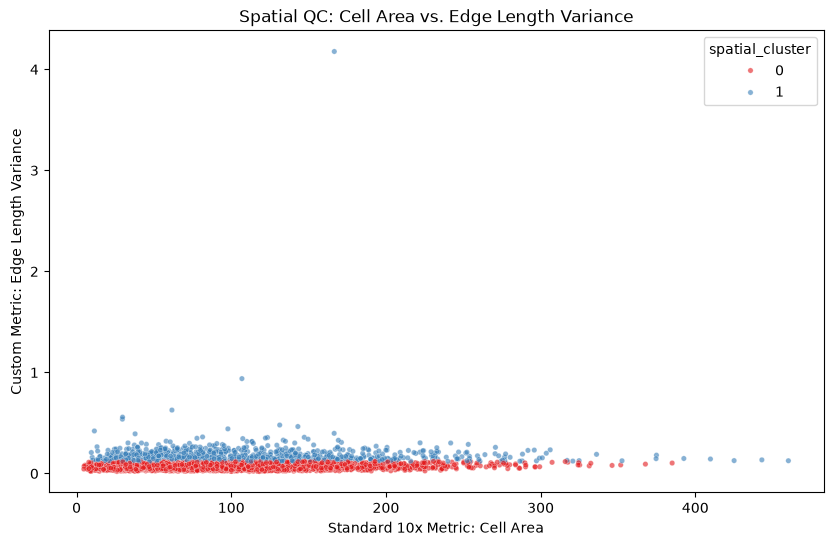

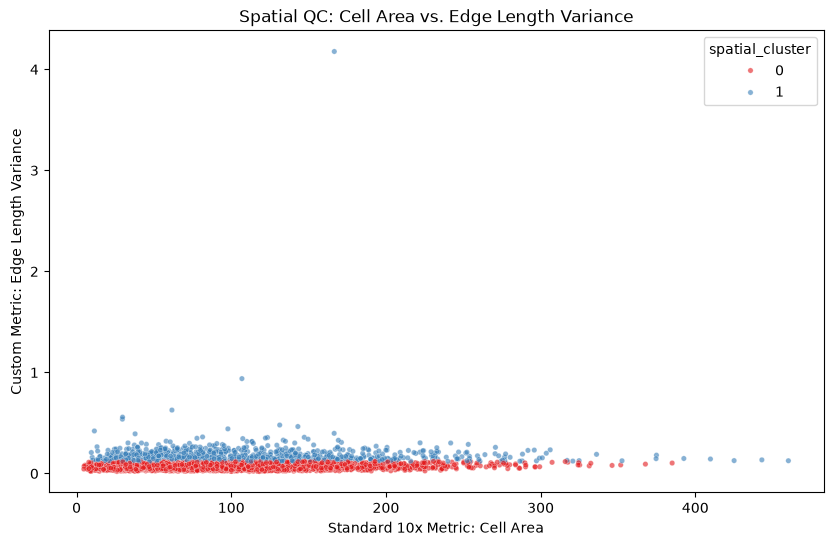

In [ ]:

plotter = SubQCATPlotter(qc_results['merged_df'], "edge_length_variance")
plotter.scatter_plot()


In [12]:
qc_results['correlations']

{'transcript_counts': np.float64(-0.37970289787803146),
 'cell_area': np.float64(-0.14398221987848375),
 'nucleus_area': np.float64(-0.27455897052089734)}